# Práctica 2

Descripción: Sucesiones y series de números reales. 

Bibliografía:
 
 Kong, Q, Siauw, T. and Bayen, A. M., "Python Programming and Numerical Methods". Elsevier.
 Sympy documentation: https://docs.sympy.org/latest/index.html
 Meurer, A. et alt., "SymPy: symbolic computing in Python". PeerJ Computer Science.
                

## Algunas observaciones previas con el manejo de los números reales con Python

Python utiliza "floating point" números para trabajar con los números reales. Ello conlleva situaciones como las siguientes. Ejecuta los comandos.

In [1]:
import numpy as np
import math
import sympy as sy

In [2]:
0.1 + 0.2 + 0.3 == 0.6

False

In [3]:
0.1 + 0.2 + 0.3

0.6000000000000001

Esto se debe a la imposibilidad de representar de forma exacta los números, dado que son aproximaciones. La cantidad de números con los puede trabajar el ordenador es finita. La solución para evitar el problema anterior sería

In [4]:
round(0.1 + 0.2 + 0.3) == round(0.6)

True

Si queremos trabajar con un número de decimales concreto podemos utilizar la función Float() de SymPy.

In [5]:
sy.Float(math.pi, 5) + sy.Float(2.143187, 5)

5.2848

## Sucesiones

Para cálculo simbólico utilizaremos el módulo sympy. Podemos cargarlo por completo o únicamente aquello que necesitamos. Para más información es interesante consultar la guía de SymPy. También es de destacar que para utilizar cálculo simbólico algunos elementos del módulo math no funcionarán como esperamos y que se pueden utilizar con el módulo SymPy.

In [6]:
#from sympy import limit_seq
#from sympy.abc import n
n = sy.Symbol('n')  #Trata a n como un simbolo

Veamos como definir sucesiones. Observa que previamente hemos de indicar que n es un símbolo. Otra forma de hacerlo es 

In [7]:
a = (3*n**2 + 5)/(n**2 + 1)
sy.limit_seq(a, n)   #Nos devuelve el limite

3

También podemos generar una lista con términos de la sucesión. Veamos un ejemplo.

In [8]:
sucesion1 = [a.subs(n,i) for i in range(10)]
print(sucesion1, end ='')

[5, 4, 17/5, 16/5, 53/17, 40/13, 113/37, 76/25, 197/65, 124/41]

Observa que utilizando SymPy obtenemos resultados exactos. Si queremos obtener el valor numérico podemos utilizar las funciones "N" o "evalf"

In [9]:
sucesion1 = [sy.N(a.subs(n,i), 7) for i in range(10)]  #Sy.N nos lo da con decimales, el ,7 nos dice el número de ellos
print(sucesion1, end='')

[5.000000, 4.000000, 3.400000, 3.200000, 3.117647, 3.076923, 3.054054, 3.040000, 3.030769, 3.024390]

In [10]:
a2 = 3**(2*n - 1)

In [11]:
sy.limit_seq(a2, n)

oo

In [12]:
sucesion2 = [sy.N(a2.subs(n, i)) for i in range(10)]
print(sucesion2, end='')

[0.333333333333333, 3.00000000000000, 27.0000000000000, 243.000000000000, 2187.00000000000, 19683.0000000000, 177147.000000000, 1594323.00000000, 14348907.0000000, 129140163.000000]

In [13]:
a3 = 2 + (-1)**n
sy.limit_seq(a3, n)

AccumBounds(1, 3)

In [14]:
sucesion3 = [a3.subs(n, i) for i in range(10)]
print(sucesion3, end='')

[3, 1, 3, 1, 3, 1, 3, 1, 3, 1]

Vamos a representar gráficamente las sucesiones a1, a2 y a3. Para ello necesitamos cargar pyplot de matplotlib

In [15]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'n')

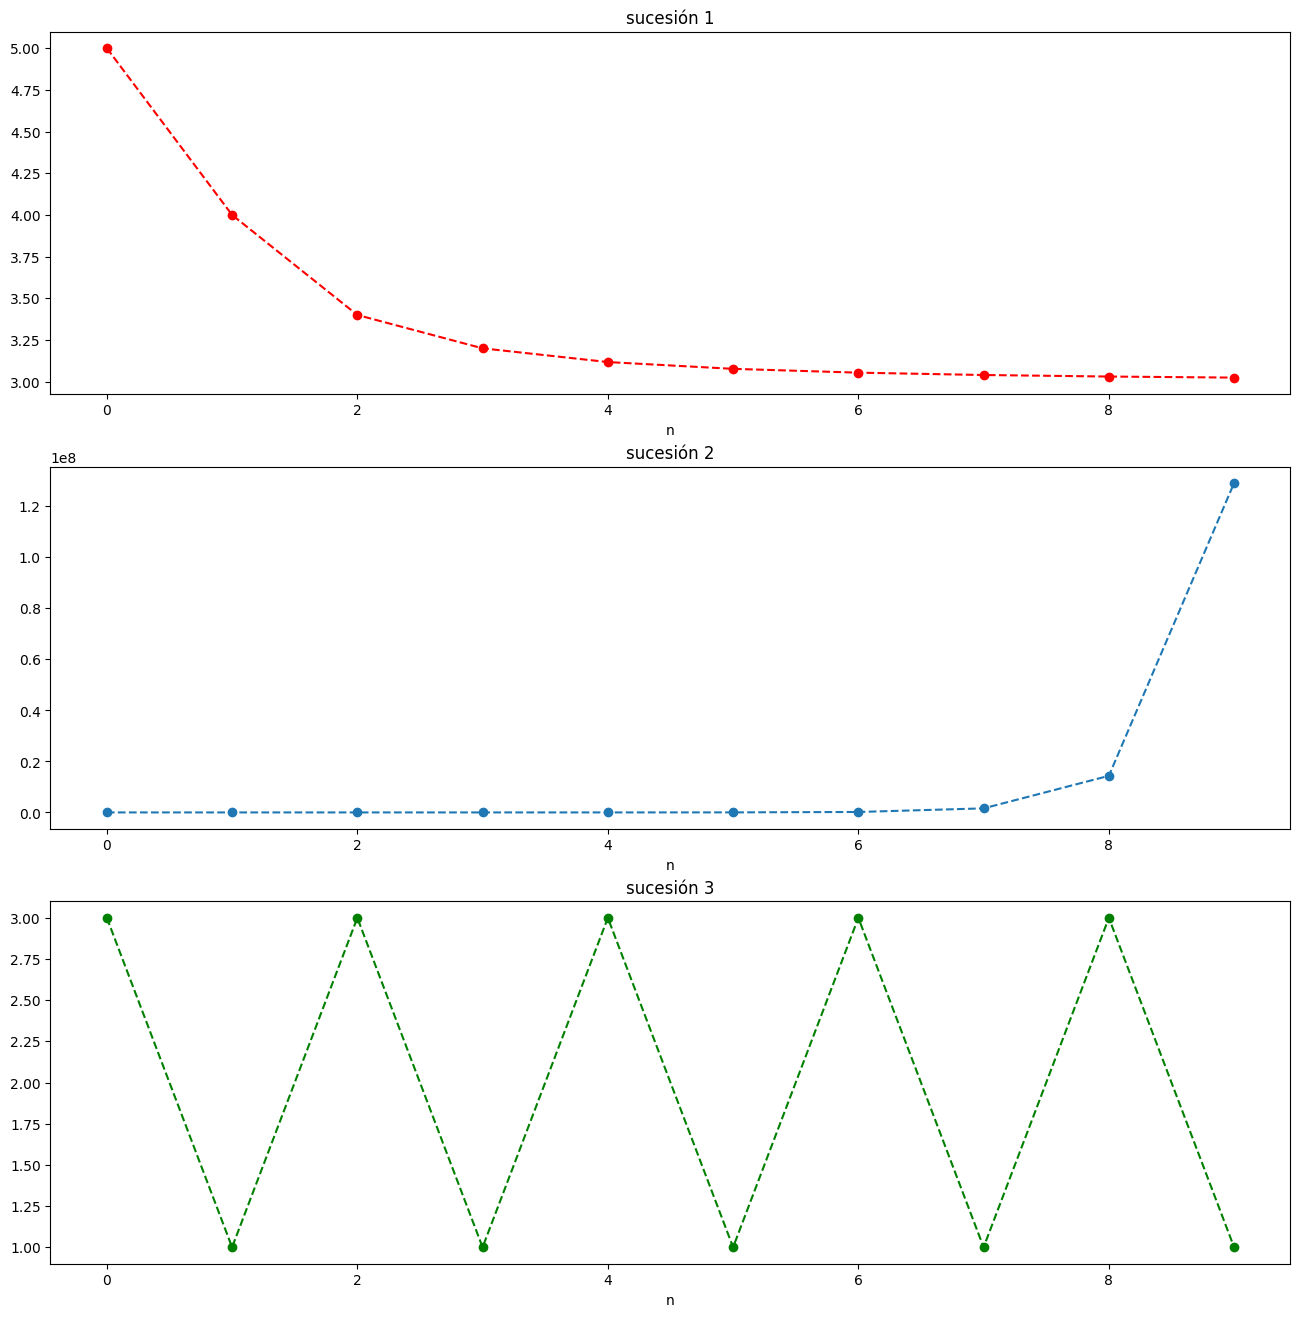

In [16]:
fig, axs = plt.subplots(3, 1, figsize= (16, 16))
axs[0].plot(sucesion1, '--o', color='r')
axs[0].set_title('sucesión 1')
axs[0].set_xlabel('n')
axs[1].plot(sucesion2, '--o')
axs[1].set_title('sucesión 2')
axs[1].set_xlabel('n')
axs[2].plot(sucesion3, '--o', color='g')
axs[2].set_title('sucesión 3')
axs[2].set_xlabel('n')


Calcula el límite de las siguientes sucesiones:
1. $\lim_{n\rightarrow \infty} \left(1-\frac{1}{n^2}\right)^n$

2. $\lim_{n\rightarrow \infty} \frac{\log(n)}{\log(2n)}$

3. $\lim_{n\rightarrow \infty} \frac{n!}{2^n 3^n}$




In [17]:
##Introduzca aquí el código
a1 = (1 - 1/n**2)
sy.limit_seq(a1, n)

1

In [18]:
a2 = (sy.log(n))/(sy.log(2 * n))
sy.limit_seq(a2, n)

1

In [19]:
a3 = (sy.factorial(n))/(2**n * 3**n)
sy.limit_seq(a3, n)

oo

¿Qué sucede con las sucesiones definidas de forma recursiva? Vamos a ver lo que sucede con la sucesión de Fibonacci que vimos anteriormente. 

In [20]:
def fibonacci(n):
    '''Calcula el n-ésimo término de la sucesión de Fibonacci'''
    int(n)
    x = [1, 1]
    if n == 1:
        return(1)
    elif n == 2:
        return(1)
    else:
        for i in range(2, n):
            x.append(x[i-1] + x[i-2])
        return(x[n-1])

In [21]:
sucesion5 = [fibonacci(i) for i in range(1, 10)]
sucesion5

[1, 1, 2, 3, 5, 8, 13, 21, 34]

In [22]:
sucesion6 = [fibonacci(i+1)/fibonacci(i) for i in range(1, 20)]
print(sucesion6, end='')

[1.0, 2.0, 1.5, 1.6666666666666667, 1.6, 1.625, 1.6153846153846154, 1.619047619047619, 1.6176470588235294, 1.6181818181818182, 1.6179775280898876, 1.6180555555555556, 1.6180257510729614, 1.6180371352785146, 1.618032786885246, 1.618034447821682, 1.6180338134001253, 1.618034055727554, 1.6180339631667064]

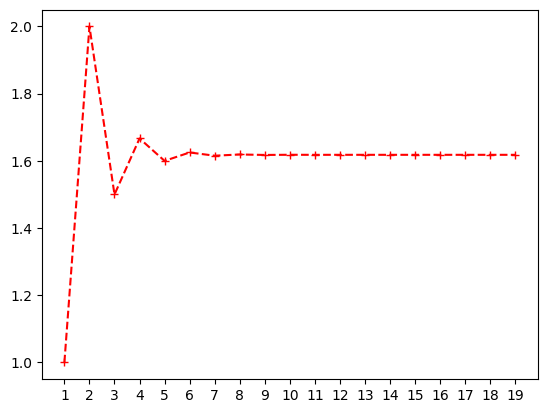

In [23]:
fig, ax = plt.subplots()
x = 1 + np.arange(19)      #Para empezar en el 1
plt.plot(x, sucesion6, '--+', color='r')
plt.xticks(x)
plt.show()


Define la función dada de forma recursiva por $a_1=1$, $a_{n+1}= a_n+\frac{1}{2^n}$. Dibuja los 20 primeros términos.

Ejercicio:

a) $\textbf{(Realizar a mano)}$. Sea la sucesión $(x_n)_n$ definida por $x_1=3$ y

$$x_{n+1}=\frac{3+3 x_n}{3+x_n}.$$

a.1) Demuestre que la sucesión es decreciente.

Observación: Escriba cuál es la condición para ser decreciente e intente demostrar la desigualdad.

a.2) Justifique que existe el límite $l=\lim_{n\rightarrow \infty} x_n$.

Observación: Utiliza la propiedad anterior y aplica la teoría para deducir la existencia del límite. Una vez que hayas probado la existencia puedes calcularlo.

b) $\textbf{(Realizar con el ordenador)}$. 

b.1) Vamos a definir una función que calcule el término $n$-ésimo de la sucesión. El usuario debe introducir el primer término de la sucesión, en este caso $x_1=3$ y el valor de $n$ para que la función devuelva $x_n$. Lo primero que debes observar es que esta sucesión es recurrente, ¿por qué? Fíjate en la sucesión de Fibonacci como modelo. 

b.2) Ahora queremos ver cómo se comporta, para ello calcula los 100 primeros términos de la sucesión, es decir,
$$\{x_1,x_2,\ldots, x_{100}\}.$$

b.3) Representa los puntos de la lista en pares de la forma $\{(1,x_1), (2,x_2), (3,x_3),\ldots, (100,x_{100})\}$, únelos.

b.4) De los anteriores apartados, numéricamente, ¿qué obtienes?

b.5) Repite el proceso ahora con $200$ términos y extrae conclusiones.

### Apartado 1

In [24]:
#Función de la sucesión
def sucesionXn(n):
    x = [3]
    if n == 1:
        return(3)
    else:
        for i in range(1, n):
            x.append((3 + 3 * (x[i - 1]))/(3 + x[i - 1]))
        return(x[n - 1])

            

### Apartado 2

In [25]:
#Mostrar los 100 primeros valores
cien_terminos = [sucesionXn(i) for i in range(1, 101)]
print(cien_terminos)

[3, 2.0, 1.8, 1.7500000000000002, 1.736842105263158, 1.7333333333333336, 1.7323943661971832, 1.7321428571428572, 1.732075471698113, 1.7320574162679423, 1.7320525783619816, 1.7320512820512817, 1.7320509347060413, 1.732050841635177, 1.732050816696915, 1.7320508100147274, 1.732050808224241, 1.7320508077444816, 1.73205080761593, 1.732050807581485, 1.7320508075722552, 1.732050807569782, 1.7320508075691199, 1.7320508075689423, 1.7320508075688947, 1.7320508075688823, 1.7320508075688785, 1.7320508075688776, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688772, 1.7320508075688774, 1.7320508075688

### Apartado 3

In [26]:
#Representar los puntos de la lista en pares 
for i in range(1, 101):
    print(f"({i}, {cien_terminos[i - 1]})")

(1, 3)
(2, 2.0)
(3, 1.8)
(4, 1.7500000000000002)
(5, 1.736842105263158)
(6, 1.7333333333333336)
(7, 1.7323943661971832)
(8, 1.7321428571428572)
(9, 1.732075471698113)
(10, 1.7320574162679423)
(11, 1.7320525783619816)
(12, 1.7320512820512817)
(13, 1.7320509347060413)
(14, 1.732050841635177)
(15, 1.732050816696915)
(16, 1.7320508100147274)
(17, 1.732050808224241)
(18, 1.7320508077444816)
(19, 1.73205080761593)
(20, 1.732050807581485)
(21, 1.7320508075722552)
(22, 1.732050807569782)
(23, 1.7320508075691199)
(24, 1.7320508075689423)
(25, 1.7320508075688947)
(26, 1.7320508075688823)
(27, 1.7320508075688785)
(28, 1.7320508075688776)
(29, 1.7320508075688772)
(30, 1.7320508075688774)
(31, 1.7320508075688772)
(32, 1.7320508075688774)
(33, 1.7320508075688772)
(34, 1.7320508075688774)
(35, 1.7320508075688772)
(36, 1.7320508075688774)
(37, 1.7320508075688772)
(38, 1.7320508075688774)
(39, 1.7320508075688772)
(40, 1.7320508075688774)
(41, 1.7320508075688772)
(42, 1.7320508075688774)
(43, 1.73205080

#### Apartado número 4
##### De los apartados anteriores obtengo que la sucesión recurrente converge en el número 3  


## Series de números reales

Comenzamos con un ejemplo. Vamos a generar la serie geométrica $\{1, \frac{1}{2}, \frac{1}{2^2},\ldots, \frac{1}{2^n},\ldots,...\}$. 

In [27]:
# Recuerda n debe ser un símbolo
n = sy.Symbol('n')
a = 1/2**n
sucesion8 = [a.subs(n,i) for i in range(10)]
print(sucesion8, end ='')

[1, 1/2, 1/4, 1/8, 1/16, 1/32, 1/64, 1/128, 1/256, 1/512]

También podemos ahora construir una nueva serie con las sumas parciales. $S_n= \sum_{i=0}^n \frac{1}{2^i}$, es decir,
$\{1, 1+\frac{1}{2}, 1+\frac{1}{2}+\frac{1}{2^2}, \ldots,\}$

In [28]:
sucesion8[0:5]

[1, 1/2, 1/4, 1/8, 1/16]

In [29]:
sumaparcial = [sum(sucesion8[0:i+1]) for i in range(10)]
sumaparcial

[1, 3/2, 7/4, 15/8, 31/16, 63/32, 127/64, 255/128, 511/256, 1023/512]

Vamos a visualizar ahora ambas sucesiones

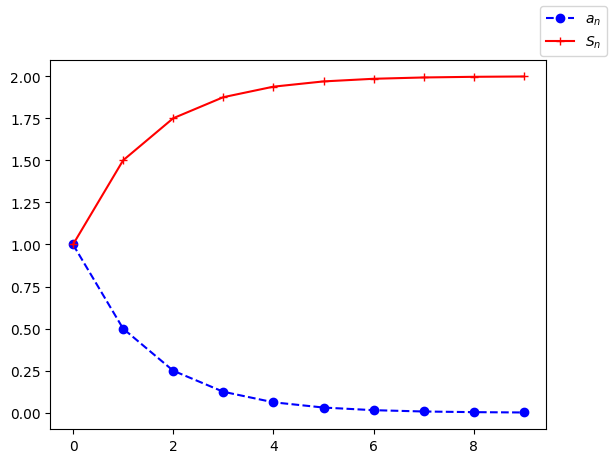

In [30]:
fig, ax = plt.subplots()
ax.plot(sucesion8, '--o', color ='b', label ='$a_n$')
ax.plot(sumaparcial, '-+', color ='r', label ='$S_n$')
fig.legend()


Podemos observar como la gráfica color azul se aproxima a $0$, mientras que la roja lo hace a $2$.

Utilizando SymPy podemos obtener algunos resultados de series de números. Veamos la forma de realizarlo.

In [31]:
i = sy.Symbol('i')
sumaparcial2 = sy.summation(1/2**i, (i, 0, n))
sumaparcial2

2 - 2*2**(-n - 1)

Para simplificar podemos utilizar el método simplify.

In [32]:
sumaparcial2.simplify()

2 - 1/2**n

Podemos realizar también sumas infinitas.

In [33]:
sumaparcial3 = sy.summation(1/2**i, (i, 0, sy.oo))
sumaparcial3

2

Si calculamos la suma de los 10 primeros términos obtenemos

In [34]:
sumaparcial4 = sy.summation(1/2**i, (i, 0, 10))
sy.N(sumaparcial4)

1.99902343750000

Observa que la suma de los 10 primeros términos es un valor muy próximo al resultado final. 

Calcule las sumas:

$\sum_{n=1}^\infty \frac{4}{(4n-3)(4n+1)}$

$\sum_{n=0}^{\infty} (-1)^n \frac{5}{4^n}$


In [35]:
## Escribe el código
n = sy.Symbol("n")
sy.summation(4 /((4 *n - 3) * (4 * n + 1)), (n, 1, sy.oo))

1

In [36]:
sy.summation((-1)**n * 5/4**n, (n, 0, sy.oo))

4

In [37]:
# El guión bajo hace referencia al resultado que ha sido previamente calculado.
sy.simplify(_)

4

Vamos a analizar la siguiente serie
$$\sum_{n=1}^{\infty} \frac{1}{n^3 \sin^2(n)}.$$
En principio no conocemos si la serie converge o diverge. Realiza los siguientes pasos.

1. Define la sucesión de sumas parciales 
$$S_k=\sum_{n=1}^k \frac{1}{n^3 \sin^2(n)}.$$

In [ ]:
##  Escribe el código
def suma_parcial2(k):
    aux = [(1 / (n**3 * (math.sin(n)**2))) for n in range(1, k + 1)]
    return(sum(aux[0:k + 1]))

TypeError: 'Infinity' object cannot be interpreted as an integer

2. Dibuja los 100 primeros puntos de la sucesión de las sumas parciales. ¿Qué observas?

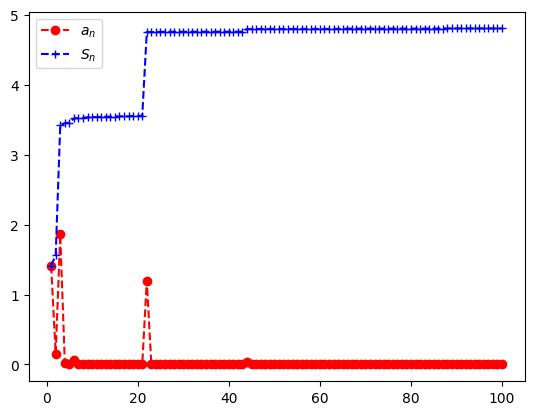

In [39]:
# Escribe el código
suma_parcial2(1)


fig, ax = plt.subplots()
x = 1 + np.arange(100)
suc1 = [(1 / (n**3 * (math.sin(n)**2))) for n in range(1, 101)]
suc2 = [suma_parcial2(n) for n in range(1, 101)]
plt.plot(x, suc1, "--o", color="r", label="$a_n$")
plt.plot(x, suc2, "--+", color="b", label="$S_n$")
plt.legend()


3. Repite el procedimiento para los 200 primeros puntos

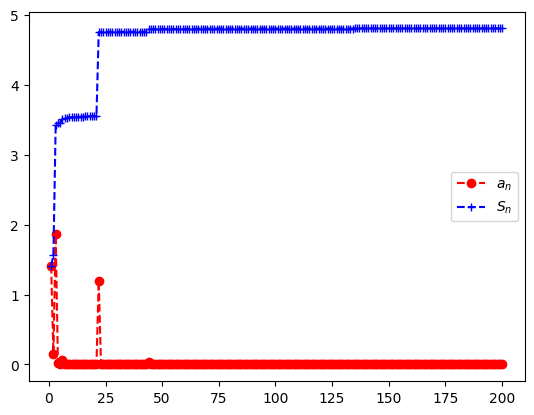

In [40]:
## Escribe el código
fig, ax = plt.subplots()
x = 1 + np.arange(200)
suc1 = [(1 / (n**3 * (math.sin(n)**2))) for n in range(1, 201)]
suc2 = [suma_parcial2(n) for n in range(1, 201)]
plt.plot(x, suc1, "--o", color="r", label="$a_n$")
plt.plot(x, suc2, "--+", color="b", label="$S_n$")
plt.legend()

4. Después repite el procedimiento con los 400 primeros puntos. ¿Qué ocurre?

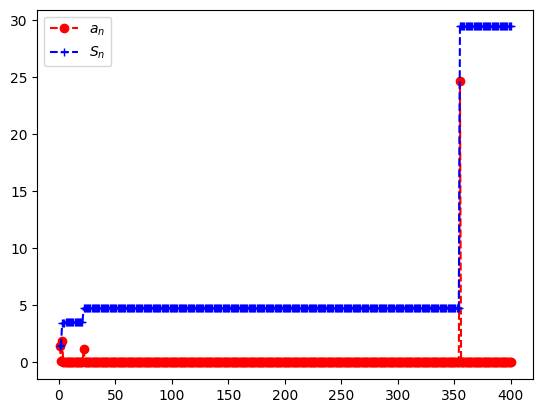

In [41]:
fig, ax = plt.subplots()
x = 1 + np.arange(400)
suc1 = [(1 / (n**3 * (math.sin(n)**2))) for n in range(1, 401)]
suc2 = [suma_parcial2(n) for n in range(1, 401)]
plt.plot(x, suc1, "--o", color="r", label="$a_n$")
plt.plot(x, suc2, "--+", color="b", label="$S_n$")
plt.legend()

Observa que para valores próximos a 355 se produce un salto. ¿Cuál es la razón? Observa que $355$ es aproximadamente igual a $113\cdot \pi$ y $\sin(113 \cdot \pi)=0$. 

In [42]:
355/113

3.1415929203539825

Puedes obtener más información sobre esta serie en "Mazes for the Mind"  de Clifford A. Pickover, Capítulo 72.